### import necessary libraries

In [1]:
import pandas as pd
from nltk.sentiment.vader import SentimentIntensityAnalyzer
import matplotlib.pyplot as plt


### Load News Data and Compute Daily Sentiment

In [2]:
# Initialize VADER sentiment analyzer
sia = SentimentIntensityAnalyzer()

# Load news dataset
news_df = pd.read_csv(r"C:\Users\Administrator\Downloads\challenge-week1\challenge-week1\data\raw_analyst_ratings.csv")

# Convert 'date' column to datetime safely
news_df['Date'] = pd.to_datetime(news_df['date'], errors='coerce')

# Drop invalid dates
news_df = news_df.dropna(subset=['Date'])

# Compute sentiment for each headline
news_df['Sentiment'] = news_df['headline'].apply(lambda x: sia.polarity_scores(str(x))['compound'])

# Aggregate sentiment per day
daily_sentiment = (
    news_df.groupby(news_df['Date'].dt.date)['Sentiment']
    .mean()
    .reset_index()
    .rename(columns={'Sentiment':'Daily_Sentiment'})
)

# Convert to datetime64[ns] for merging
daily_sentiment['Date'] = pd.to_datetime(daily_sentiment['Date'])


### Load Stock Data and Compute Daily Returns

In [3]:
# List of stock symbols
stock_names = ['AAPL','AMZN','GOOG','META','MSFT','NVDA']

stocks = {}
for name in stock_names:
    file = rf"C:\Users\Administrator\Downloads\challenge-week1\challenge-week1\data\{name}.csv"
    
    df = pd.read_csv(file)
    
    # Convert 'Date' to datetime64
    df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
    
    # Drop rows with invalid dates
    df = df.dropna(subset=['Date'])
    
    # Sort by date
    df = df.sort_values('Date')
    
    # Compute daily returns
    df['Daily_Return'] = df['Close'].pct_change()
    
    stocks[name] = df


### Merge Stocks With News Sentiment

In [4]:
merged_data = {}
for name, df in stocks.items():
    merged = pd.merge(df, daily_sentiment, on='Date', how='left')
    merged_data[name] = merged


### Check Data Overlap

In [5]:
# Optional: check how many rows have both return and sentiment
for name, df in merged_data.items():
    valid_rows = df[['Daily_Return','Daily_Sentiment']].dropna().shape[0]
    print(f"{name}: {valid_rows} valid rows for correlation")


AAPL: 2226 valid rows for correlation
AMZN: 2226 valid rows for correlation
GOOG: 2226 valid rows for correlation
META: 1984 valid rows for correlation
MSFT: 2226 valid rows for correlation
NVDA: 2226 valid rows for correlation


### Compute Correlations

In [6]:
correlations = {}
for name, df in merged_data.items():
    corr = df['Daily_Return'].corr(df['Daily_Sentiment'])
    correlations[name] = corr

# Display correlations
correlations_df = pd.DataFrame.from_dict(correlations, orient='index', columns=['Correlation']).sort_values('Correlation', ascending=False)
correlations_df


,Correlation
AAPL,0.045257
MSFT,0.028714
NVDA,0.026551
GOOG,0.024689
AMZN,-0.001526
META,-0.007372


### plot AAPL daily sentiment vs returns

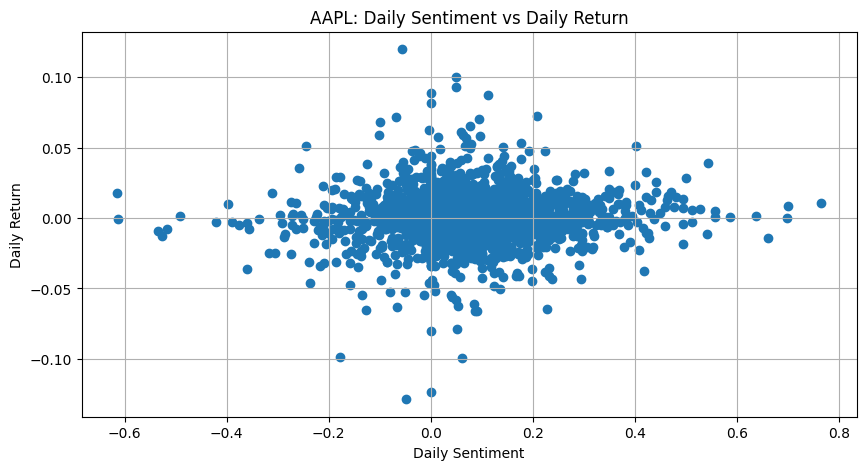

In [7]:
# Example: plot AAPL daily sentiment vs returns
df = merged_data['AAPL']

plt.figure(figsize=(10,5))
plt.scatter(df['Daily_Sentiment'], df['Daily_Return'])
plt.title("AAPL: Daily Sentiment vs Daily Return")
plt.xlabel("Daily Sentiment")
plt.ylabel("Daily Return")
plt.grid(True)
plt.show()


### Plot Daily Sentiment vs Daily Return for Multiple Stocks

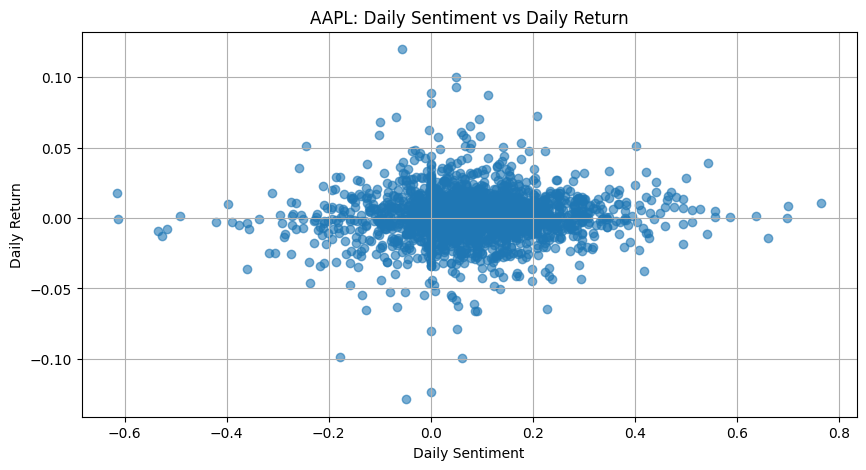

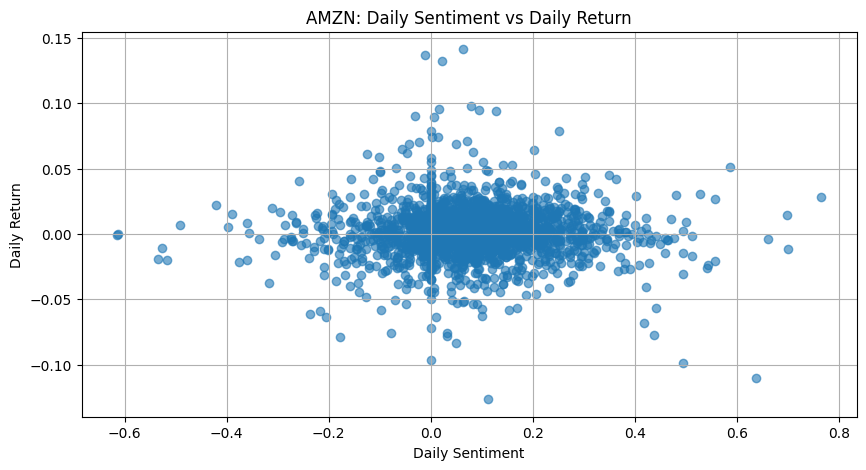

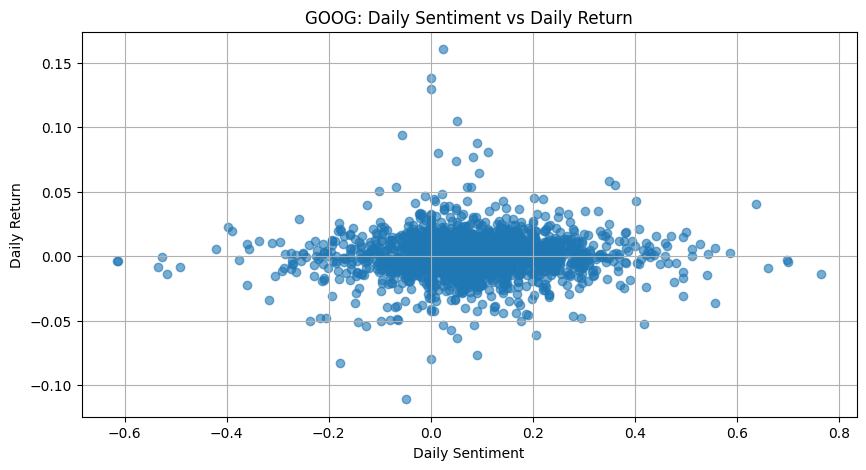

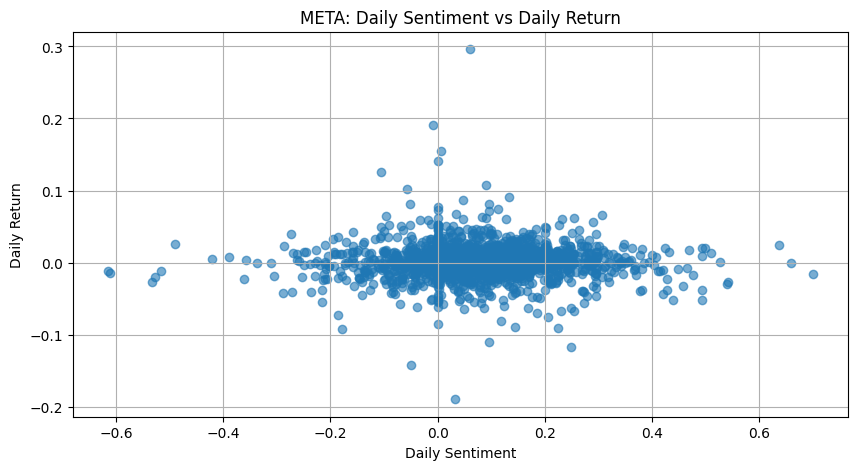

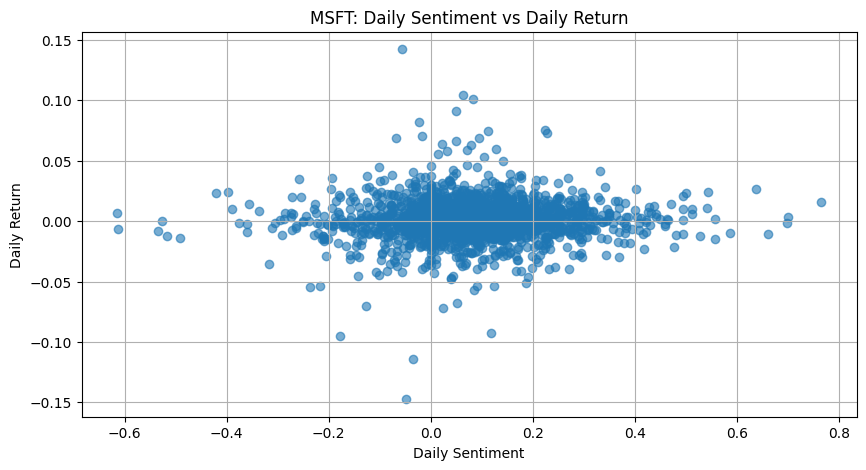

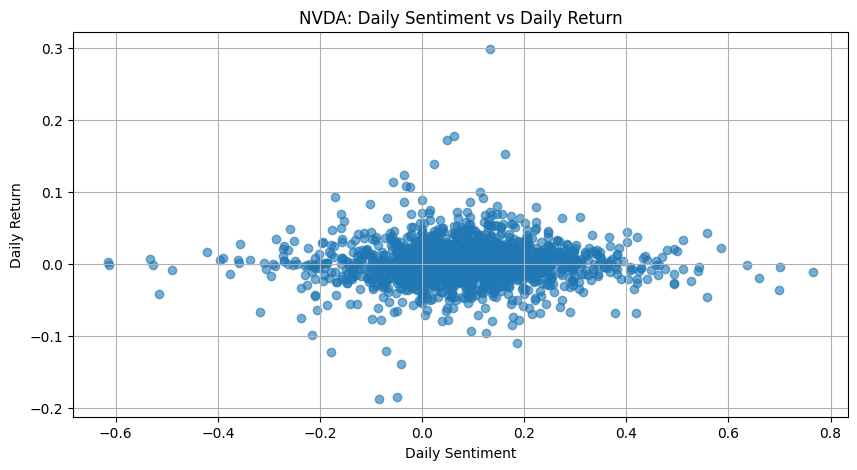

In [8]:
import matplotlib.pyplot as plt

# List of stocks to plot
stocks_to_plot = ['AAPL','AMZN','GOOG','META','MSFT','NVDA']

for name in stocks_to_plot:
    df = merged_data[name].dropna(subset=['Daily_Return','Daily_Sentiment'])
    
    plt.figure(figsize=(10,5))
    plt.scatter(df['Daily_Sentiment'], df['Daily_Return'], alpha=0.6)
    plt.title(f"{name}: Daily Sentiment vs Daily Return")
    plt.xlabel("Daily Sentiment")
    plt.ylabel("Daily Return")
    plt.grid(True)
    plt.show()
